# PHANOTATE-rs Hybrid ML Scorer — Training Notebook

This notebook trains machine learning models to predict adjustment factors
for PHANOTATE's ORF scoring. The adjustment is applied as a multiplicative
residual to the heuristic score (RBS + GC-frame + start-codon).

## Workflow

1. **Load features** exported via `phanotate-rs --export-features`
2. **Load labels** from annotated genomes (or use heuristic pseudo-labels)
3. **Explore features** — distributions, correlations, importance
4. **Train models** — XGBoost, Random Forest, Logistic Regression
5. **Evaluate** — ROC, PR curves, calibration
6. **Export to ONNX** for Rust inference
7. **Validate end-to-end** — run PHANOTATE with the model

## Prerequisites

```bash
pip install numpy pandas matplotlib seaborn scikit-learn xgboost onnx skl2onnx onnxmltools jupyter
```

In [1]:
import os
os.environ["DYLD_LIBRARY_PATH"] = "/opt/homebrew/Cellar/libomp/22.1.7/lib"
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, mean_squared_error, r2_score
)

# XGBoost
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("Warning: xgboost not installed. Install with: pip install xgboost")

# ONNX export
try:
    import onnx
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    from onnxmltools import convert_xgboost
    HAS_ONNX = True
except ImportError:
    HAS_ONNX = False
    print("Warning: skl2onnx not installed. ONNX export will not be available.")

# Plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully")
print(f"  XGBoost: {HAS_XGB}")
print(f"  ONNX export: {HAS_ONNX}")

Libraries loaded successfully
  XGBoost: True
  ONNX export: True


In [2]:
from skl2onnx import convert_sklearn

---
## 1. Configuration

Set paths to your feature TSV and label files.

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────

# Path to PHANOTATE-rs binary (for generating features / running predictions)
PHANOTATE_RS = "../target/release/phanotate-rs"  # adjust as needed

# Feature TSV generated via: phanotate-rs --export-features features.tsv
FEATURES_PATH = "../scripts/data/100_genomes_features.tsv"

# Optional: label file with 'is_gene' column (1 = true gene, 0 = false ORF)
# If None, uses heuristic-based pseudo-labels
LABELS_PATH = "../scripts/data/100_genomes_labels.tsv"  # "../labels.tsv"

# Output directory for models and plots
OUTPUT_DIR = "./models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Feature names (must match src/ml_features.rs FEATURE_NAMES)
FEATURE_NAMES = [
    "log_length", "rbs_score_norm", "log_hold", "pstop",
    "weight_rbs_log", "start_codon_atg", "start_codon_gtg",
    "start_codon_ttg", "gc_content", "frame_fwd",
    "frame_1", "frame_2", "frame_3",
]

print(f"Output directory: {OUTPUT_DIR}")
print(f"Features file: {FEATURES_PATH}")
print(f"Labels file: {LABELS_PATH or '(using pseudo-labels)'}")

Output directory: ./models
Features file: ../scripts/data/100_genomes_features.tsv
Labels file: ../scripts/data/100_genomes_labels.tsv


---
## 2. Generate Features (if needed)

Run PHANOTATE-rs with `--export-features` to generate training data.

In [ ]:
# def export_features(genome_fasta, output_tsv, phanotate_bin=PHANOTATE_RS):
#     """Run phanotate-rs --export-features on a genome."""
#     if os.path.exists(output_tsv):
#         print(f"Features already exist: {output_tsv}")
#         return
    
#     cmd = [phanotate_bin, "-i", genome_fasta, "--export-features", output_tsv]
#     print(f"Running: {' '.join(cmd)}")
#     result = subprocess.run(cmd, capture_output=True, text=True)
#     if result.returncode != 0:
#         print(f"Error: {result.stderr}")
#         raise RuntimeError("Feature export failed")
#     print(f"Exported to: {output_tsv}")

# # Example: export features from a test genome
# # export_features("../tests/golden/phiX174.fasta_out", FEATURES_PATH)

---
## 3. Load and Inspect Data

In [4]:
def load_data(features_path, labels_path=None):
    """Load feature TSV and optional labels."""
    features = pd.read_csv(features_path, sep="\t")
    
    # Ensure all expected columns are present
    missing = set(FEATURE_NAMES) - set(features.columns)
    if missing:
        raise ValueError(f"Missing columns in feature file: {missing}")
    
    X = features[FEATURE_NAMES].values.astype(np.float32)
    
    if labels_path and os.path.exists(labels_path):
        labels = pd.read_csv(labels_path, sep="\t")
        if "is_gene" not in labels.columns:
            raise ValueError("Label file must contain 'is_gene' column")
        if len(labels) != len(features):
            raise ValueError(f"Row count mismatch: {len(features)} features vs {len(labels)} labels")
        y = labels["is_gene"].values.astype(np.float32)
        print(f"Loaded {len(y)} samples with true labels ({y.sum():.0f} genes, {len(y)-y.sum():.0f} non-genes)")
    else:
        # Pseudo-labels: use heuristic score quartiles
        # High heuristic score (more negative) → likely gene
        # We approximate using length + RBS as a simple heuristic
        heuristic = features["log_length"] + features["rbs_score_norm"] * 2
        threshold = heuristic.quantile(0.5)
        y = (heuristic >= threshold).astype(np.float32).values
        print(f"Using pseudo-labels (heuristic-based): {y.sum():.0f} positive, {len(y)-y.sum():.0f} negative")
    
    return X, y, features

# Load data
if not os.path.exists(FEATURES_PATH):
    raise FileNotFoundError(f"Features file not found: {FEATURES_PATH}. Run export_features() first or set FEATURES_PATH.")

X, y, df_features = load_data(FEATURES_PATH, LABELS_PATH)
print(f"\nFeature matrix shape: {X.shape}")
print(f"Feature dtypes: {X.dtype}")

Loaded 2172083 samples with true labels (124194 genes, 2047889 non-genes)

Feature matrix shape: (2172083, 13)
Feature dtypes: float32


### 3.1 Feature Distributions

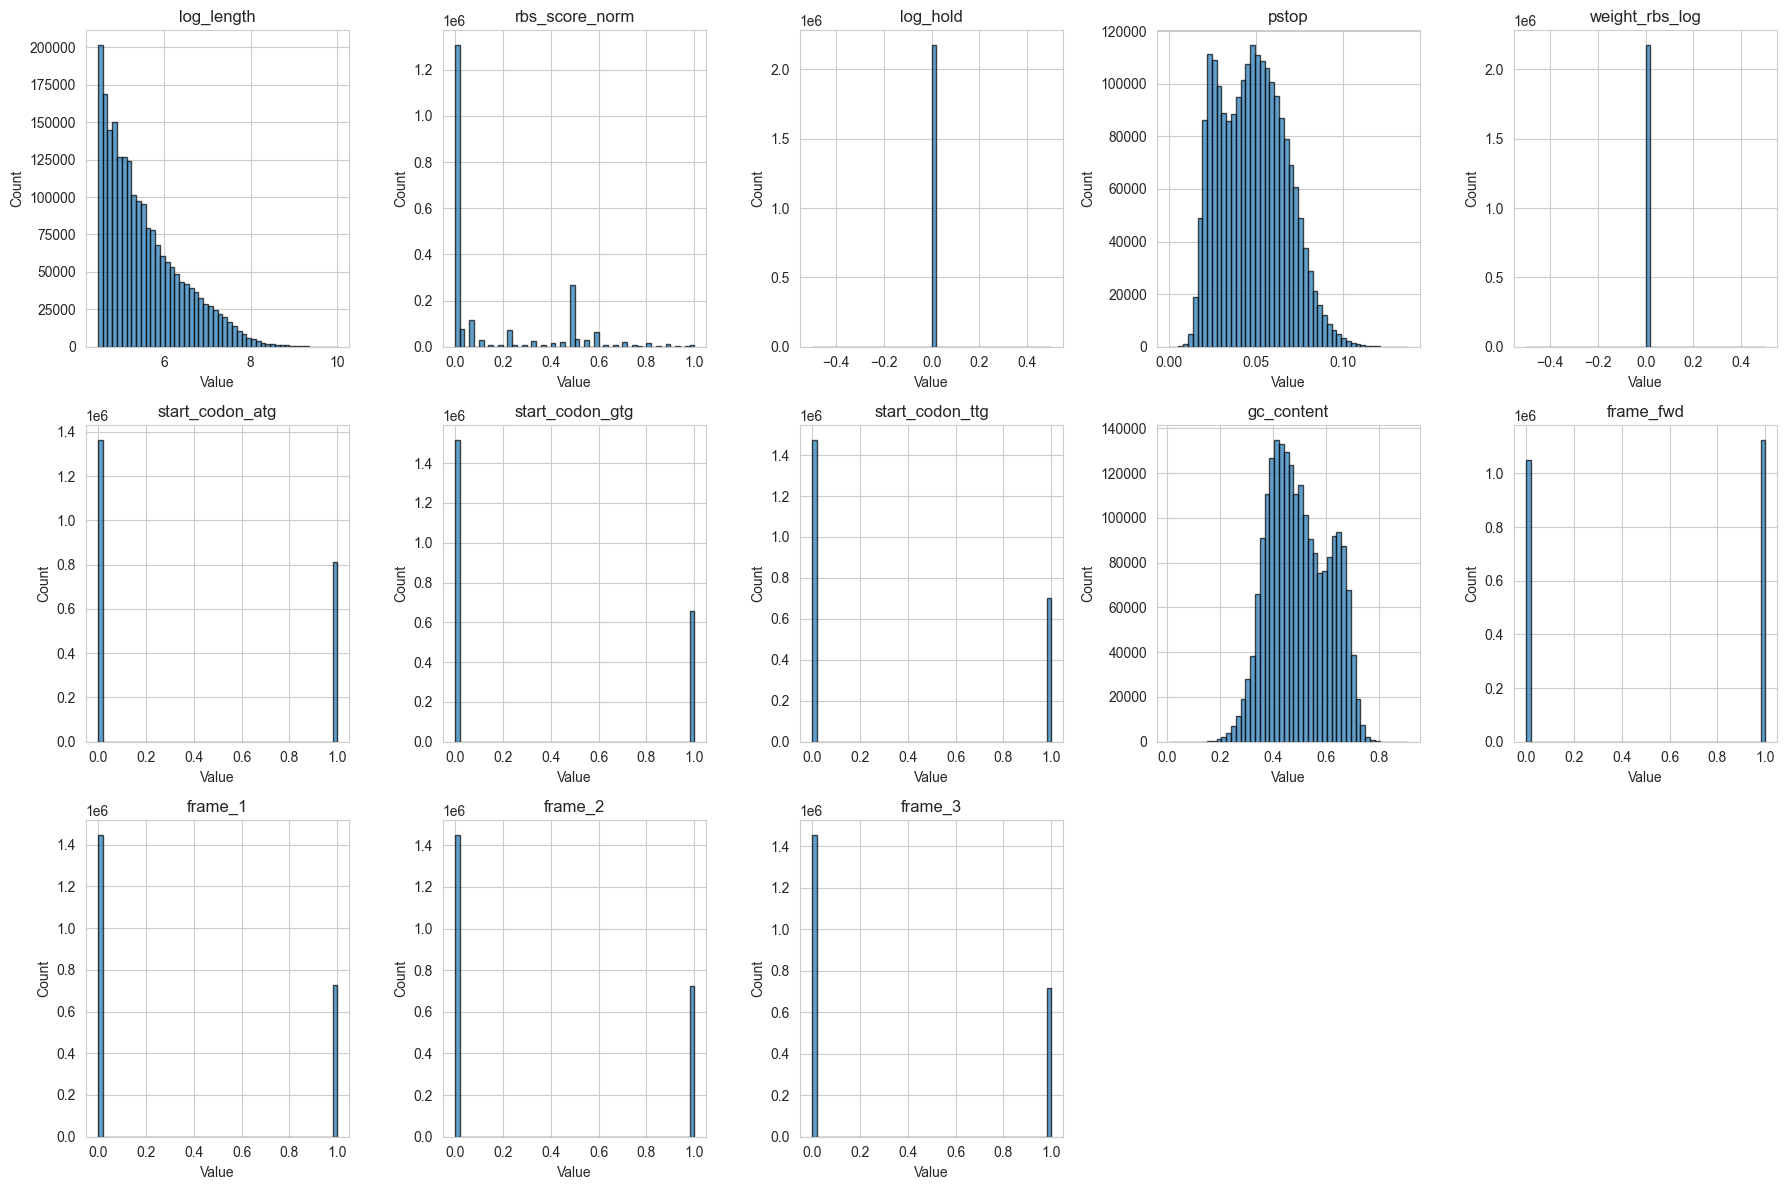

Saved: ./models/feature_distributions.png


In [5]:
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.flatten()

for i, name in enumerate(FEATURE_NAMES):
    ax = axes[i]
    data = df_features[name]
    ax.hist(data, bins=50, alpha=0.7, edgecolor='black')
    ax.set_title(name)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

# Hide extra subplot
axes[-1].axis('off')
axes[-2].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/feature_distributions.png")

### 3.2 Feature Correlations

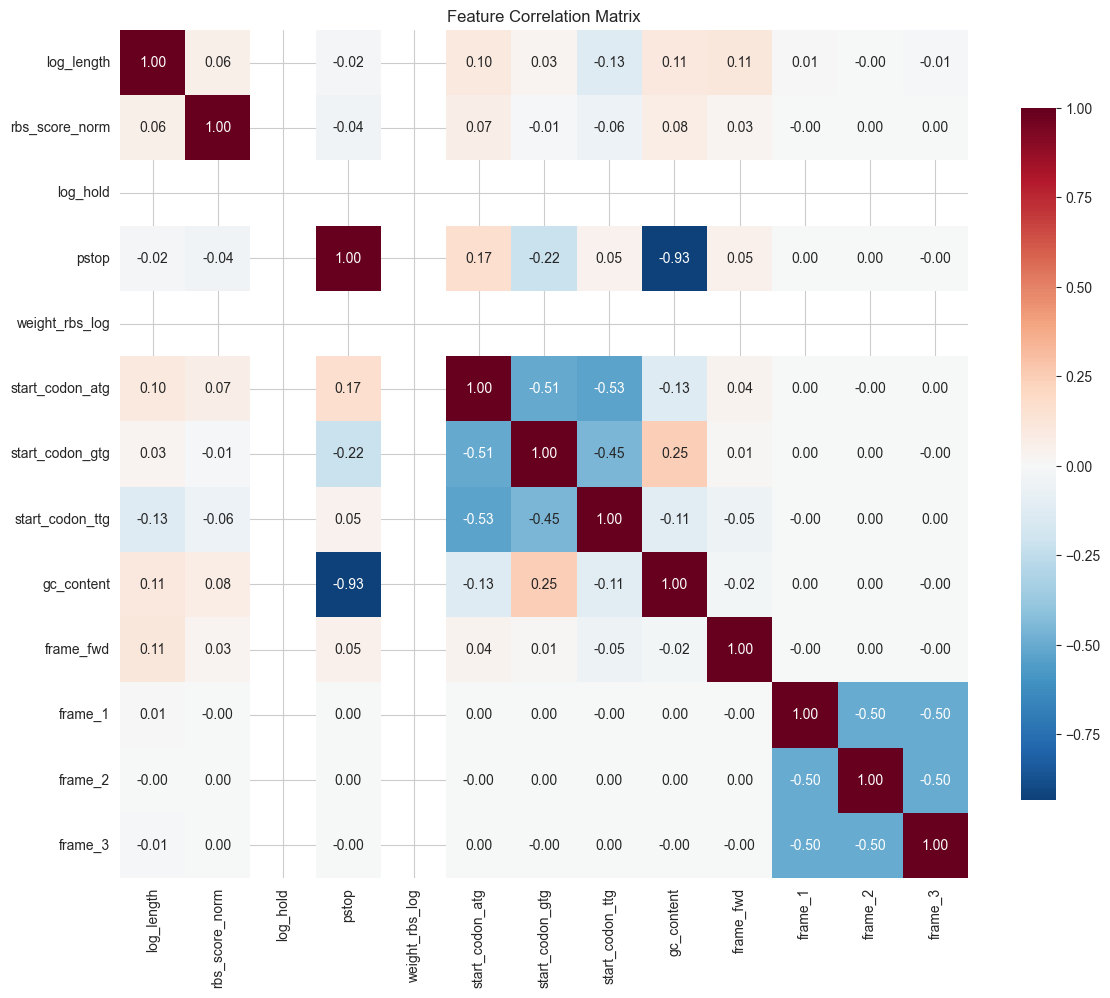

In [6]:
corr = df_features[FEATURE_NAMES].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_correlations.png", dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Features vs Label

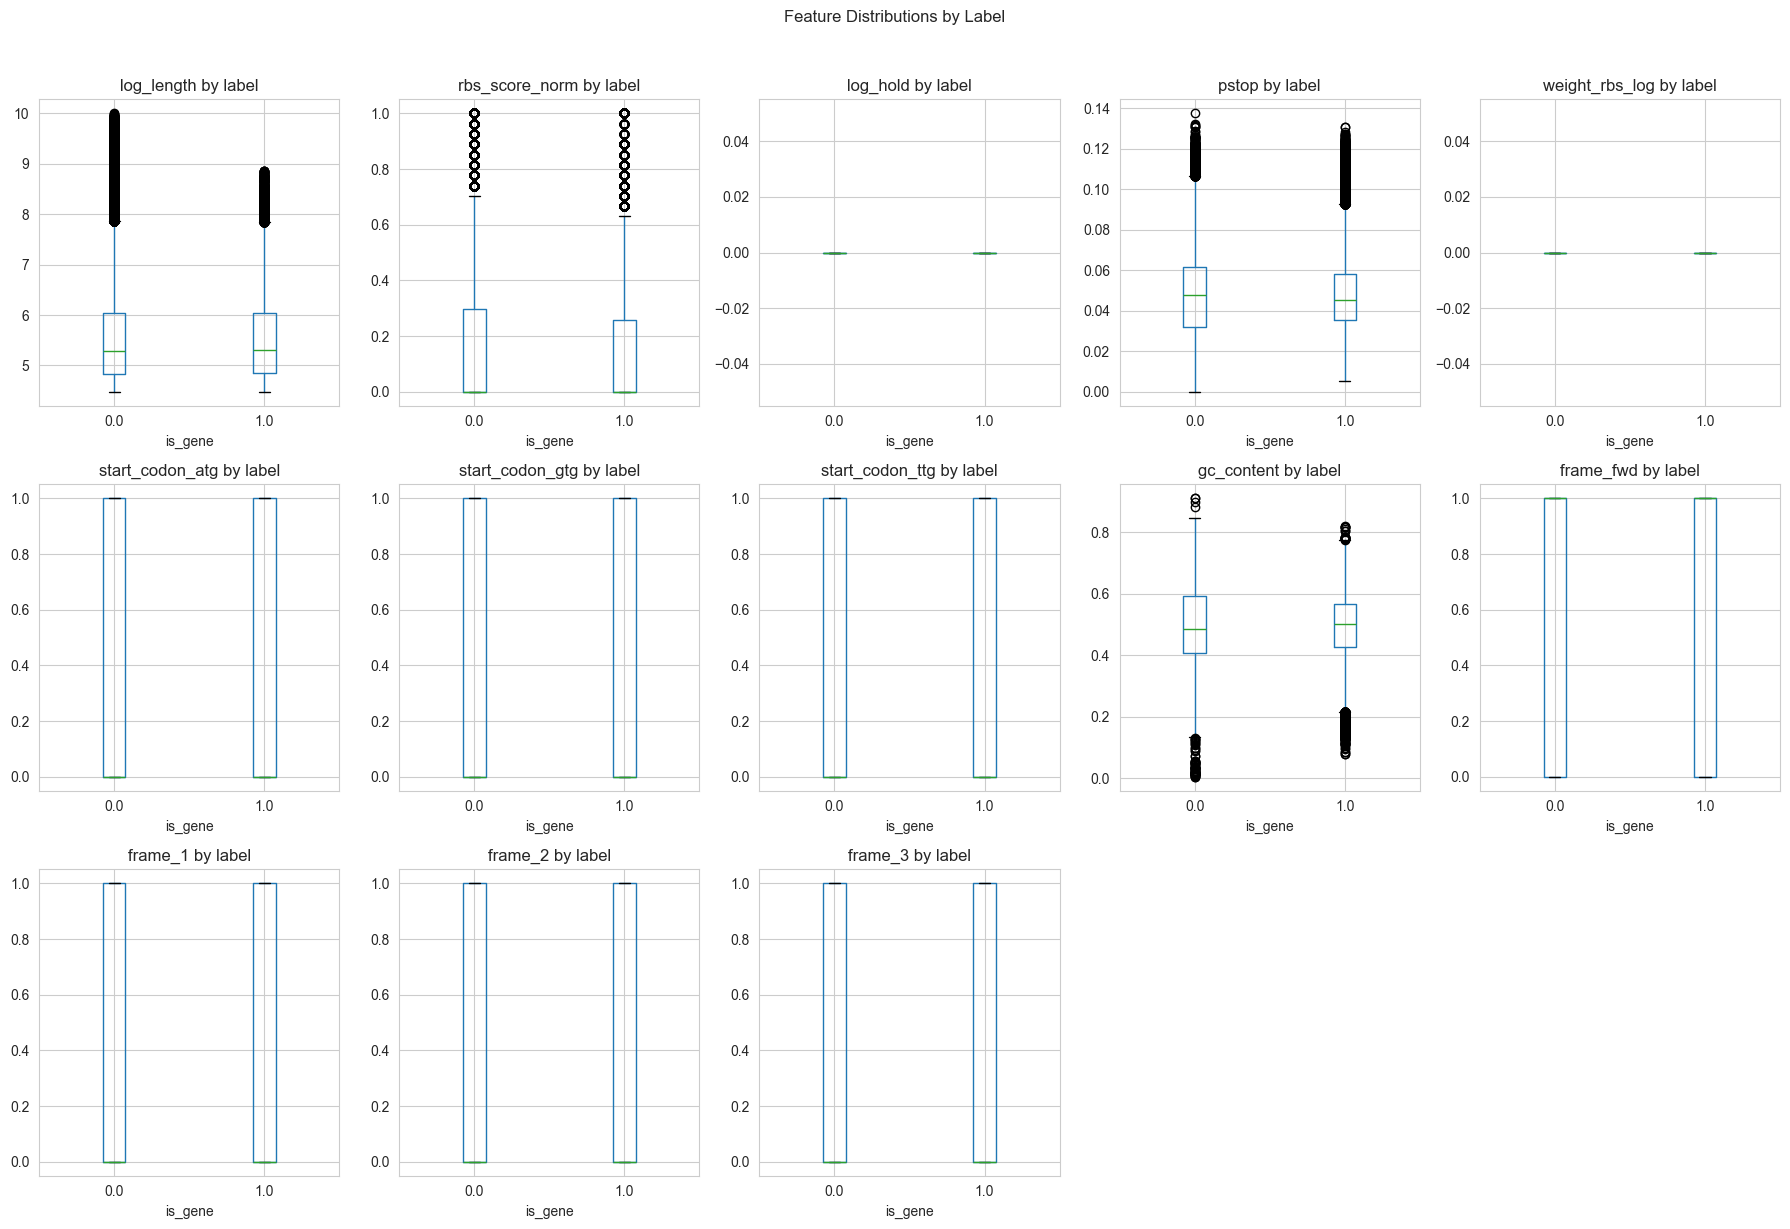

In [7]:
df_features['is_gene'] = y

fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.flatten()

for i, name in enumerate(FEATURE_NAMES):
    ax = axes[i]
    df_features.boxplot(column=name, by='is_gene', ax=ax)
    ax.set_title(f"{name} by label")
    ax.set_xlabel("is_gene")

axes[-1].axis('off')
axes[-2].axis('off')
plt.suptitle("Feature Distributions by Label", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/features_by_label.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Train/Test Split

In [8]:
# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} samples ({y_train.sum():.0f} positive)")
print(f"Test:  {len(X_test)} samples ({y_test.sum():.0f} positive)")

# Standard scaler for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: 1737666 samples (99355 positive)
Test:  434417 samples (24839 positive)


---
## 5. Model Training

We train two types of models:

1. **Classifier** — predicts P(gene | features) directly
2. **Regressor** — predicts log-adjustment factor (matches the Rust scorer design)

The Rust scorer expects a **regressor** outputting log-scale adjustments.

### 5.1 Logistic Regression (baseline)

In [9]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_lr)
ap_lr = average_precision_score(y_test, y_pred_lr)

print(f"Logistic Regression — AUC: {auc_lr:.4f}, AP: {ap_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, (y_pred_lr > 0.5).astype(int)))

Logistic Regression — AUC: 0.5128, AP: 0.0600

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97    409578
         1.0       0.00      0.00      0.00     24839

    accuracy                           0.94    434417
   macro avg       0.47      0.50      0.49    434417
weighted avg       0.89      0.94      0.92    434417



/Users/javis/miniconda3/envs/phanotate_rs/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/javis/miniconda3/envs/phanotate_rs/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/javis/miniconda3/envs/phanotate_rs/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

### 5.2 Random Forest Classifier

Random Forest — AUC: 0.6244, AP: 0.1055


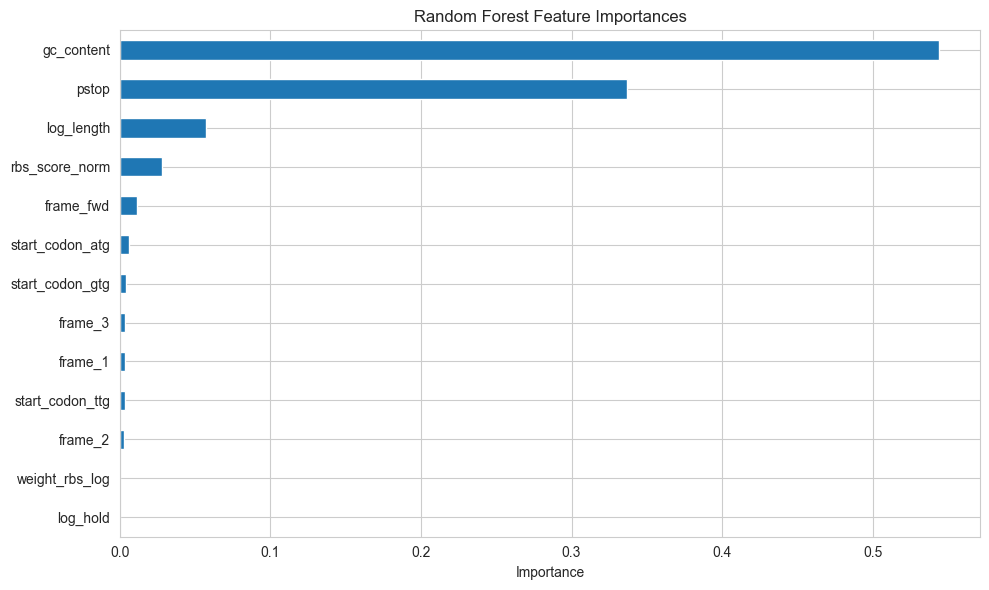

In [10]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_pred_rf)
ap_rf = average_precision_score(y_test, y_pred_rf)

print(f"Random Forest — AUC: {auc_rf:.4f}, AP: {ap_rf:.4f}")

# Feature importances
importances = pd.Series(rf_clf.feature_importances_, index=FEATURE_NAMES)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', ax=ax)
ax.set_title("Random Forest Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rf_importances.png", dpi=150, bbox_inches='tight')
plt.show()

### 5.3 XGBoost Regressor (for Rust scorer)

This is the model type that the Rust scorer expects. It outputs a log-scale
adjustment factor that gets exponentiated and clamped to [0.5, 2.0].

XGBoost Regressor — MSE: 1.1177, R²: 0.0265
Adjustment range: [0.500, 2.000]
Mean adjustment: 0.500


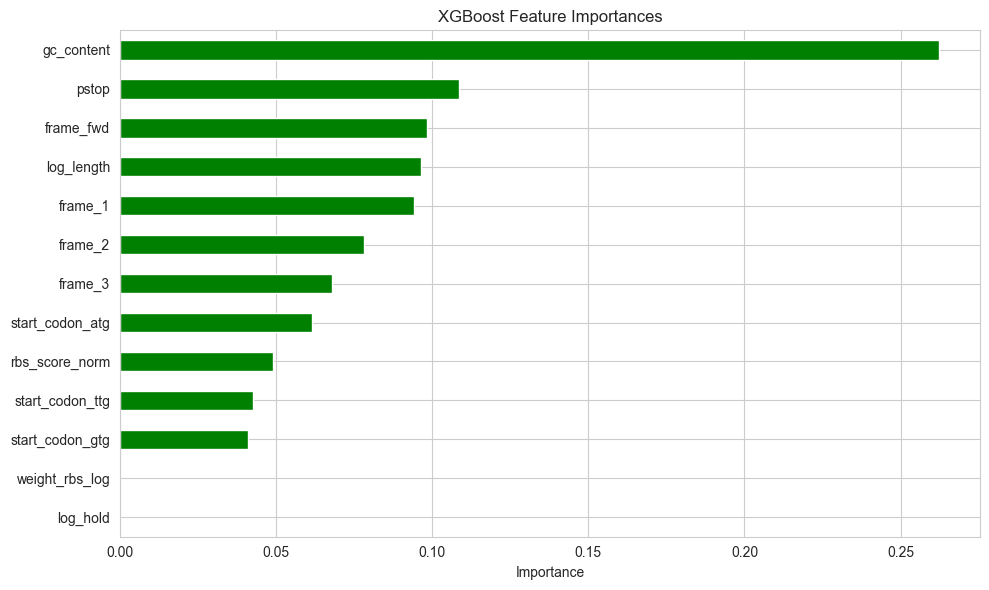

In [11]:
if not HAS_XGB:
    print("XGBoost not available. Install with: pip install xgboost")
else:
    # Target: log-adjustment
    # For genes (y=1): want adjustment > 1 → log(adjustment) > 0
    # For non-genes (y=0): want adjustment < 1 → log(adjustment) < 0
    epsilon = 0.01
    scale = 0.5  # Keep adjustments moderate
    y_train_reg = np.log((y_train + epsilon) / (1.0 - y_train + epsilon)) * scale
    y_test_reg = np.log((y_test + epsilon) / (1.0 - y_test + epsilon)) * scale
    #'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0
    xgb_reg = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.2,
        subsample=1,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
    )
    
    xgb_reg.fit(X_train, y_train_reg)
    
    y_pred_reg = xgb_reg.predict(X_test)
    mse = mean_squared_error(y_test_reg, y_pred_reg)
    r2 = r2_score(y_test_reg, y_pred_reg)
    
    print(f"XGBoost Regressor — MSE: {mse:.4f}, R²: {r2:.4f}")
    
    # Convert to adjustments and check bounds
    adjustments = np.exp(np.clip(y_pred_reg, np.log(0.5), np.log(2.0)))
    print(f"Adjustment range: [{adjustments.min():.3f}, {adjustments.max():.3f}]")
    print(f"Mean adjustment: {adjustments.mean():.3f}")
    
    # Feature importances
    xgb_imp = pd.Series(xgb_reg.feature_importances_, index=FEATURE_NAMES)
    xgb_imp = xgb_imp.sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    xgb_imp.plot(kind='barh', ax=ax, color='green')
    ax.set_title("XGBoost Feature Importances")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/xgb_importances.png", dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Model Comparison

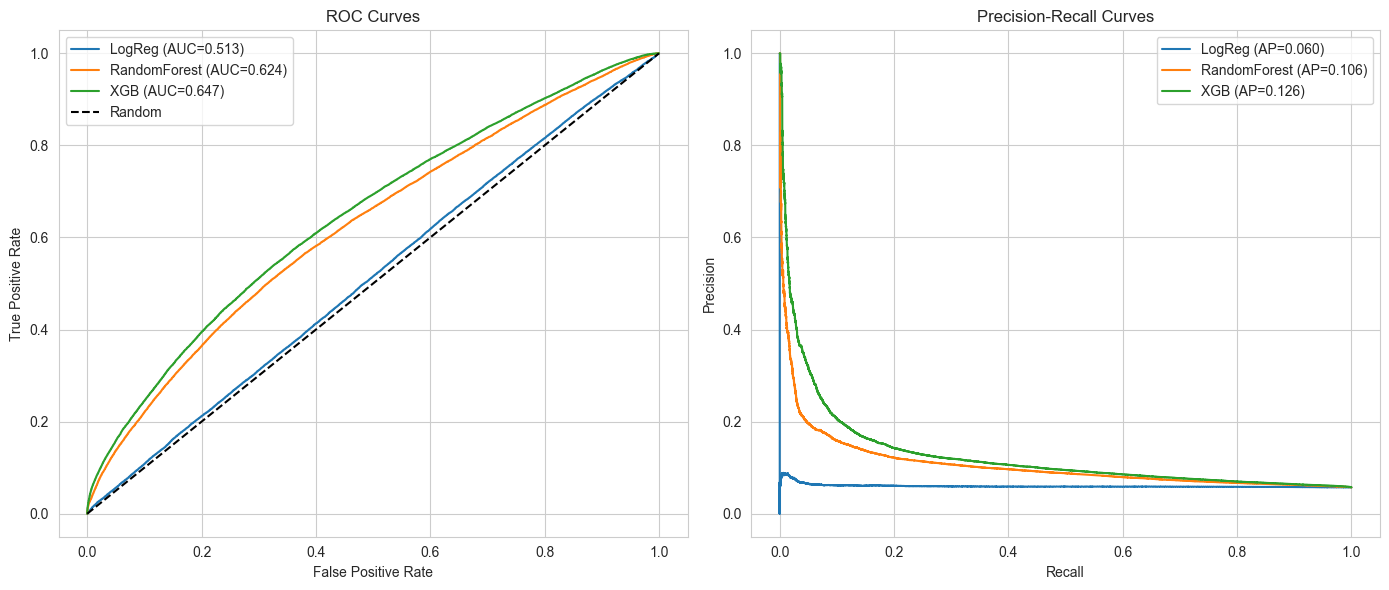

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curves
ax = axes[0]
for name, y_pred in [("LogReg", y_pred_lr), ("RandomForest", y_pred_rf), ("XGB",  y_pred_reg  )]:
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()
ax.grid(True)

# PR curves
ax = axes[1]
for name, y_pred in [("LogReg", y_pred_lr), ("RandomForest", y_pred_rf), ("XGB",  y_pred_reg  )]:
    precision, recall, _ = precision_recall_curve(y_test, y_pred)
    ap = average_precision_score(y_test, y_pred)
    ax.plot(recall, precision, label=f"{name} (AP={ap:.3f})")
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Export to ONNX

Export the best **regressor** model for use in PHANOTATE-rs Rust inference.

**Important:** PHANOTATE-rs expects a regression model with a single float output.
Classifiers (e.g. `RandomForestClassifier`, `XGBClassifier`) output class labels
and probabilities, which are not compatible. Use `RandomForestRegressor` or
`XGBRegressor` instead.

PHANOTATE-rs uses ONNX Runtime (`ort` crate) which supports all ONNX operators,
including `TreeEnsembleRegressor` from tree-based models.


In [13]:
def export_regressor_to_onnx(model, feature_names, output_path, model_type='sklearn'):
    """Export a regression model to ONNX format."""
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    from onnxmltools import convert_xgboost as convert_xgb
    
    initial_type = [("input", FloatTensorType([None, len(feature_names)]))]
    
    if model_type == 'xgboost':
        onnx_model = convert_xgb(model, initial_types=initial_type)
    elif model_type in ('sklearn', 'random_forest', 'logistic'):
        onnx_model = convert_sklearn(model, initial_types=initial_type)
    else:
        raise ValueError(f"Unsupported model type: {model_type}")
    
    with open(output_path, "wb") as f:
        f.write(onnx_model.SerializeToString())
    
    print(f"Exported ONNX model: {output_path}")
    
    # Verify with onnx
    import onnx
    model = onnx.load(output_path)
    onnx.checker.check_model(model)
    
    # Print I/O info
    print("\nModel I/O:")
    for inp in model.graph.input:
        shape = [d.dim_value if d.dim_value else '?' for d in inp.type.tensor_type.shape.dim]
        print(f"  Input:  {inp.name} -> shape={shape}")
    for out in model.graph.output:
        shape = [d.dim_value if d.dim_value else '?' for d in out.type.tensor_type.shape.dim]
        print(f"  Output: {out.name} -> shape={shape}")
    
    # Verify it's a regressor (single float output), not classifier
    output_names = [out.name for out in model.graph.output]
    if 'output_label' in output_names or 'output_probability' in output_names:
        print("\nWARNING: Model appears to be a classifier, not a regressor!")
        print("PHANOTATE-rs expects a single float output.\n")
    else:
        print("\nModel looks good for PHANOTATE-rs (regressor output).\n")
if HAS_ONNX:
    export_regressor_to_onnx(
        rf_clf, FEATURE_NAMES,
        f"{OUTPUT_DIR}/model_random_forest.onnx",
        model_type='sklearn'
    )
    
    if HAS_XGB:
        export_regressor_to_onnx(
            xgb_reg, FEATURE_NAMES,
            f"{OUTPUT_DIR}/model_xgboost.onnx",
            model_type='xgboost'
        )
else:
    print("Skipping ONNX export (libraries not installed)")

Exported ONNX model: ./models/model_random_forest.onnx

Model I/O:
  Input:  input -> shape=['?', 13]
  Output: output_label -> shape=['?']
  Output: output_probability -> shape=[]

PHANOTATE-rs expects a single float output.

Exported ONNX model: ./models/model_xgboost.onnx

Model I/O:
  Input:  input -> shape=['?', 13]
  Output: variable -> shape=['?', 1]

Model looks good for PHANOTATE-rs (regressor output).



In [14]:
# NOTE: rf_clf is a classifier. For PHANOTATE-rs, you need a regressor.
# Train a RandomForestRegressor and export that instead.
# Example:
# rf_reg = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
# rf_reg.fit(X_train, y_train_reg)  # where y_train_reg is log-ratio target
# export_regressor_to_onnx(
#     rf_reg, FEATURE_NAMES,
#     f"{OUTPUT_DIR}/model_random_forest_regressor.onnx",
#     model_type="sklearn"
# )

# For now, this cell exports the classifier (not suitable for PHANOTATE-rs):
export_regressor_to_onnx(
    rf_clf, FEATURE_NAMES,
    f"{OUTPUT_DIR}/model_random_forest.onnx",
    model_type="sklearn"
)


Exported ONNX model: ./models/model_random_forest.onnx

Model I/O:
  Input:  input -> shape=['?', 13]
  Output: output_label -> shape=['?']
  Output: output_probability -> shape=[]

PHANOTATE-rs expects a single float output.



---
## 8. End-to-End Validation

Run PHANOTATE-rs with the exported model and compare outputs.

In [15]:
def run_phanotate(genome, ml_model=None, phanotate_bin=PHANOTATE_RS):
    """Run phanotate-rs and return stdout."""
    cmd = [phanotate_bin, "-i", genome]
    if ml_model:
        cmd.extend(["--ml-model", ml_model])
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"Error: {result.stderr}")
        return None
    return result.stdout

# Test genome
TEST_GENOME = "../tests/golden/phiX174.fasta_out"

# Try the regressor model first, then fall back to any available model
MODEL_PATH = f"{OUTPUT_DIR}/model_random_forest_regressor.onnx"
if not os.path.exists(MODEL_PATH):
    MODEL_PATH = f"{OUTPUT_DIR}/model_xgboost.onnx"
if not os.path.exists(MODEL_PATH):
    MODEL_PATH = f"{OUTPUT_DIR}/model_random_forest.onnx"

if os.path.exists(TEST_GENOME) and os.path.exists(MODEL_PATH):
    print("Running baseline (no ML)...")
    baseline = run_phanotate(TEST_GENOME)
    
    print(f"Running with ML model: {MODEL_PATH}...")
    with_ml = run_phanotate(TEST_GENOME, MODEL_PATH)
    
    # Compare CDS counts
    baseline_cds = baseline.count("CDS") if baseline else 0
    ml_cds = with_ml.count("CDS") if with_ml else 0
    
    print(f"\nBaseline CDS count: {baseline_cds}")
    print(f"With ML CDS count:  {ml_cds}")
    print(f"Difference: {ml_cds - baseline_cds}")
else:
    print(f"Skipping E2E test (test genome or model not found: {MODEL_PATH})")


Running baseline (no ML)...
Running with ML model: ./models/model_random_forest_regressor.onnx...

Baseline CDS count: 21
With ML CDS count:  21
Difference: 0


---
## 9. Hyperparameter Tuning (Optional)

Grid search over XGBoost hyperparameters.

In [14]:
if HAS_XGB:
    from sklearn.model_selection import GridSearchCV
    
    param_grid = {
        'max_depth': [3, 4, 6],
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.8, 1.0],
    }
    
    grid = GridSearchCV(
        xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
        param_grid,
        scoring='neg_mean_squared_error',
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    
    print("Running grid search...")
    grid.fit(X_train, y_train_reg)
    
    print(f"\nBest params: {grid.best_params_}")
    print(f"Best CV score: {-grid.best_score_:.4f} MSE")
    
    # Evaluate best model
    best_pred = grid.predict(X_test)
    best_mse = mean_squared_error(y_test_reg, best_pred)
    print(f"Test MSE: {best_mse:.4f}")
else:
    print("XGBoost not available for hyperparameter tuning")

Running grid search...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best params: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}
Best CV score: 1.1201 MSE
Test MSE: 1.1150


---
## 10. Save Experiment Artifacts

In [ ]:
# Save a summary of this experiment
summary = {
    "n_samples": len(X),
    "n_features": len(FEATURE_NAMES),
    "n_genes": int(y.sum()),
    "n_non_genes": int(len(y) - y.sum()),
    "features": FEATURE_NAMES,
    "models": {},
}

if 'auc_lr' in globals():
    summary["models"]["logistic_regression"] = {"auc": float(auc_lr), "ap": float(ap_lr)}
if 'auc_rf' in globals():
    summary["models"]["random_forest"] = {"auc": float(auc_rf), "ap": float(ap_rf)}
if 'mse' in globals():
    summary["models"]["xgboost_regressor"] = {"mse": float(mse), "r2": float(r2)}

import json
with open(f"{OUTPUT_DIR}/experiment_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"Experiment summary saved to: {OUTPUT_DIR}/experiment_summary.json")
print("\nSummary:")
print(json.dumps(summary, indent=2))

---
## Appendix: Using the Model

After training, use the exported ONNX model with PHANOTATE-rs:

```bash
# Build with ML support (uses ONNX Runtime via `ort` crate)
cargo build --release --features ml

# Run with your model (supports tree-based and neural network models)
./target/release/phanotate-rs -i genome.fasta --ml-model ./outputs/model_random_forest_regressor.onnx

# Compare with baseline
./target/release/phanotate-rs -i genome.fasta > baseline.gbk
./target/release/phanotate-rs -i genome.fasta --ml-model model.onnx > ml.gbk
diff baseline.gbk ml.gbk
```

**Note:** PHANOTATE-rs uses ONNX Runtime (`ort` crate), which supports all ONNX
operators including `TreeEnsembleRegressor` from Random Forest and XGBoost models.
